# 03 - Exploratory Data Analysis

Explore the cleaned dataset to understand customer profiles,
loan behaviour, and the transaction engagement story before and
after the product pivot in July 2022.

In [1]:
# Set up
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from settings import PATHS, apply_pandas_settings, apply_plot_settings

apply_pandas_settings()
apply_plot_settings()

In [2]:
# Load data
customers = pd.read_csv(PATHS['clean_customers'], parse_dates = ['account_open_date'])
loans = pd.read_csv(PATHS['clean_loans'])
transactions = pd.read_csv(PATHS['clean_transactions'], parse_dates = ['transaction_date'])

In [3]:
# Verify clean dataset loaded successfully
print('Clean Data Loaded')
print(f'customers: {len(customers):,} rows')
print(f'loans: {len(loans):,} rows')
print(f'transactions: {len(transactions):,} rows')

Clean Data Loaded
customers: 5,000 rows
loans: 5,000 rows
transactions: 49,230 rows


## 1. Customer Overview

### 1.1 Acquisition Channel Distribution

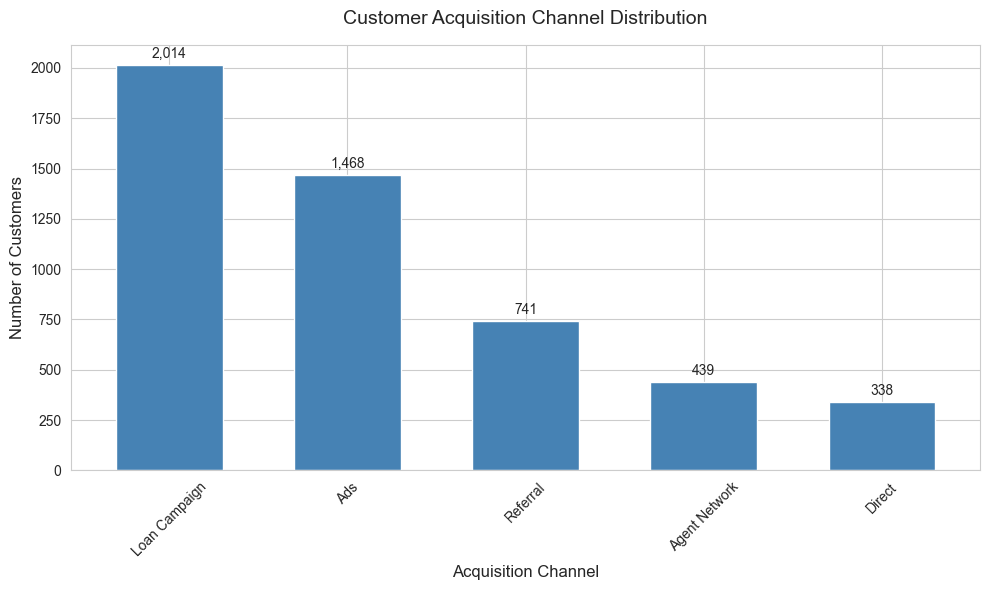

In [4]:
# How were customers acquired?
fig, ax = plt.subplots()

channel_counts = customers["acquisition_channel"].value_counts()

channel_counts.plot(
    kind="bar",
    ax=ax,
    color="steelblue",
    edgecolor="white",
    width=0.6
)

ax.set_title("Customer Acquisition Channel Distribution", pad=15)
ax.set_xlabel("Acquisition Channel")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=45)

# Add value labels on top of each bar
for i, v in enumerate(channel_counts):
    ax.text(i, v + 20, f"{v:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Insight 1.1

Loan Campaign is the dominant acquisition channel at 40.3% of the customer
base (2,014 customers) — the single largest source of customer acquisition.

Ads contributed a further 1,468 customers (29.4%), though it is unclear
from the data alone whether these ads promoted loans, transactional services,
or both.

Referral (741), Agent Network (439), and Direct (338) together account for
the remaining 30.3% of customers — channels typically associated with
word-of-mouth and organic growth rather than product-specific campaigns.


### 1.2 KYC Level Distribution

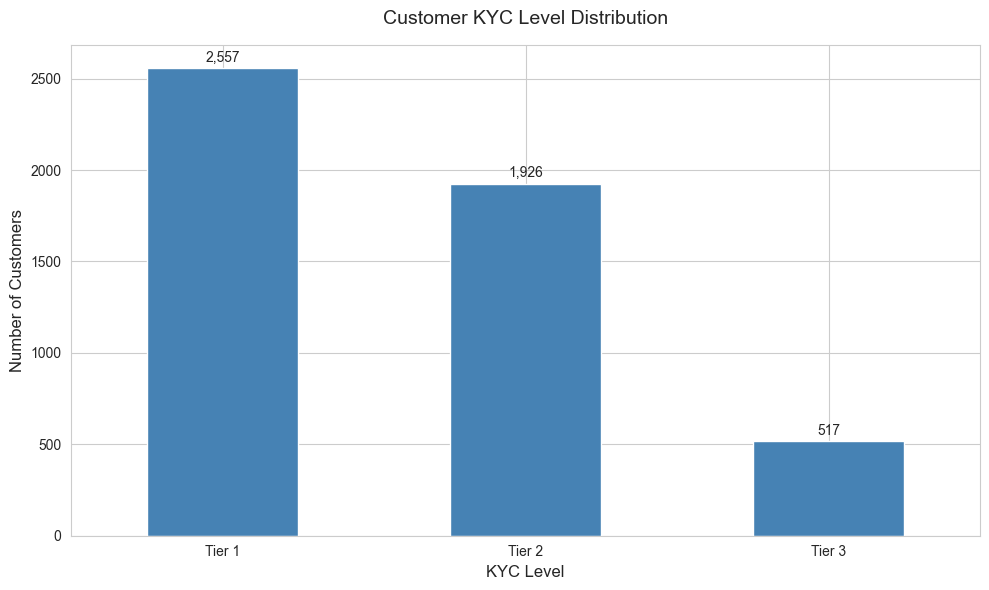

In [5]:
# How verified are our customers?
fig, ax = plt.subplots()

kyc_counts = customers["kyc_level"].value_counts().sort_index()

kyc_counts.plot(
    kind="bar",
    ax=ax,
    color="steelblue",
    edgecolor="white",
    width=0.5
)

ax.set_title("Customer KYC Level Distribution", pad=15)
ax.set_xlabel("KYC Level")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

# Add value labels
for i, v in enumerate(kyc_counts):
    ax.text(i, v + 20, f"{v:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Insight 1.2

Tier 1 customers dominate at 51.1% of the customer base (2,557 customers),
suggesting that over half of all customers completed only the minimum
verification required — consistent with customers who onboarded primarily
to access a loan rather than to engage with the full product suite.

Only 10.3% of customers (517) hold Tier 3 status and have access to the
complete post-pivot product offering including card payments and transfers.

This KYC distribution has direct implications for post-pivot engagement —
a majority of customers are restricted to a limited set of transaction types,
reducing the likelihood of meaningful retention after loans were discontinued.

### 1.3 Location Distribution

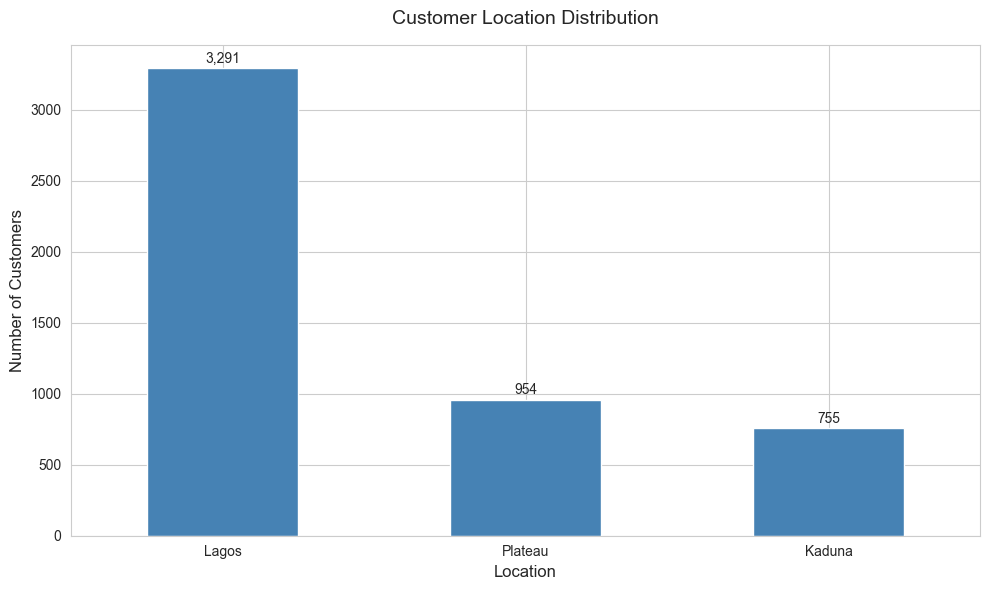

In [6]:
# How many customers by location?
fig, ax = plt.subplots()

location_counts = customers["location"].value_counts()

location_counts.plot(
    kind="bar",
    ax=ax,
    color="steelblue",
    edgecolor="white",
    width=0.5
)

ax.set_title("Customer Location Distribution", pad=15)
ax.set_xlabel("Location")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

# Add value labels
for i, v in enumerate(location_counts):
    ax.text(i, v + 20, f"{v:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Insight 1.3

Lagos accounts for 65.8% of the customer base (3,291 customers),
consistent with its position as Nigeria's primary fintech market.
Plateau (19.1%) and Kaduna (15.1%) represent smaller but meaningful
customer segments, likely reached through the Agent Network channel
given lower digital penetration in those states.

## 2. Loan Behaviour Analysis

### 2.1 Loan Uptake

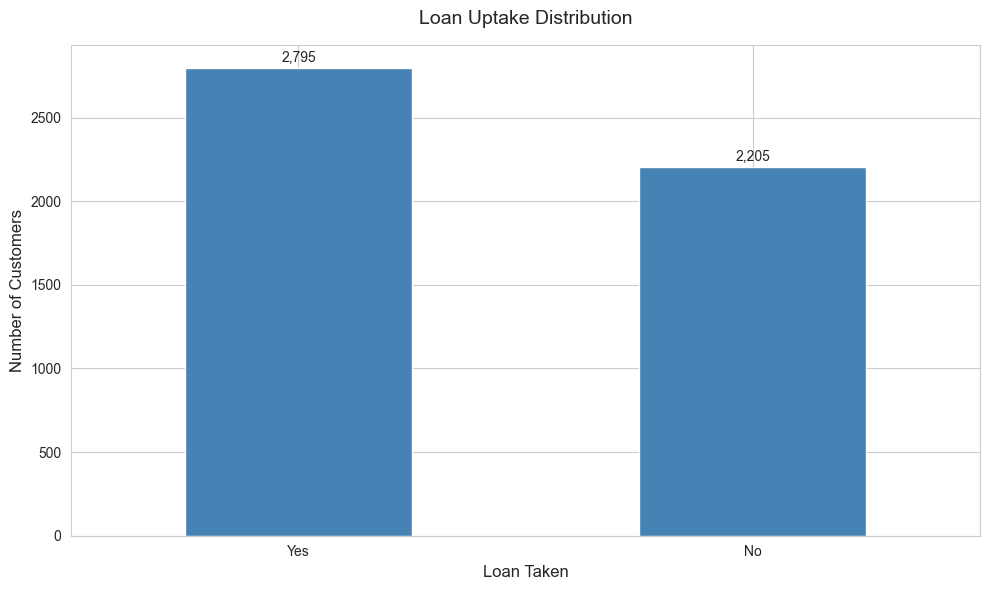

In [7]:
# Who took loans?
fig, ax = plt.subplots()

loan_counts = loans["loan_taken"].value_counts()

loan_counts.plot(
    kind="bar",
    ax=ax,
    color="steelblue",
    edgecolor="white",
    width=0.5
)

ax.set_title("Loan Uptake Distribution", pad=15)
ax.set_xlabel("Loan Taken")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

# Add value labels
for i, v in enumerate(loan_counts):
    ax.text(i, v + 20, f"{v:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Insight 2.1

55.9% of customers (2,795) took a loan while 44.1% (2,205) never did.
The relatively even split suggests the platform had meaningful engagement
beyond the loan product even before the pivot — nearly half the customer
base had no loan relationship to lose when loans were discontinued.

These 2,205 non-loan customers represent a potentially strong post-pivot
retention segment — their reasons for being on the platform were never
tied to credit.

### 2.2 Loan Default Rate

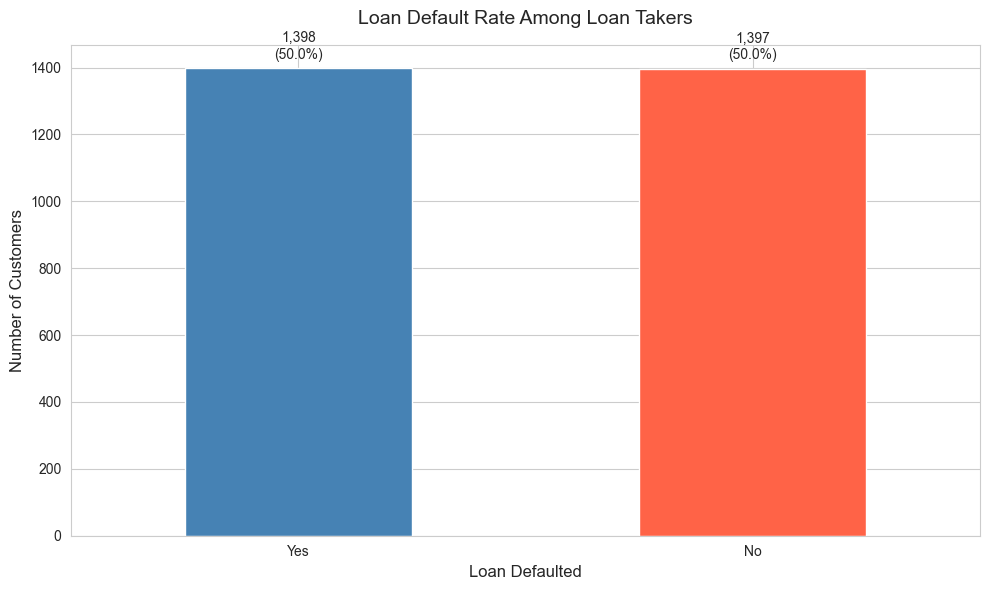

In [8]:
# Default rate analysis


# Filter to customers who took a loan only
loan_takers = loans[loans["loan_taken"] == "Yes"]

fig, ax = plt.subplots()

default_counts = loan_takers["loan_defaulted"].value_counts()

default_counts.plot(
    kind="bar",
    ax=ax,
    color=["steelblue", "tomato"],
    edgecolor="white",
    width=0.5
)

ax.set_title("Loan Default Rate Among Loan Takers", pad=15)
ax.set_xlabel("Loan Defaulted")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

# Add value labels and percentages
total = len(loan_takers)
for i, v in enumerate(default_counts):
    pct = v / total * 100
    ax.text(i, v + 20, f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Insight 2.2

Among the 2,795 customers who took a loan, exactly 50% defaulted (1,398)
and 50% repaid (1,397). A default rate of 50% is far above healthy fintech
lending benchmarks of 2–10%, making continued lending financially
unsustainable and directly triggering the product pivot.

This means 1,398 customers — 28% of the entire customer base — took a
loan and never repaid it. These customers represent the highest-risk
segment for post-pivot engagement. Having defaulted, they have both a
financial and reputational reason to disengage from the platform entirely.

The 1,397 customers who repaid their loans represent a more promising
retention target — they demonstrated financial discipline and had a
completed, positive loan experience with the platform.

### 2.3 Default Rate by Location

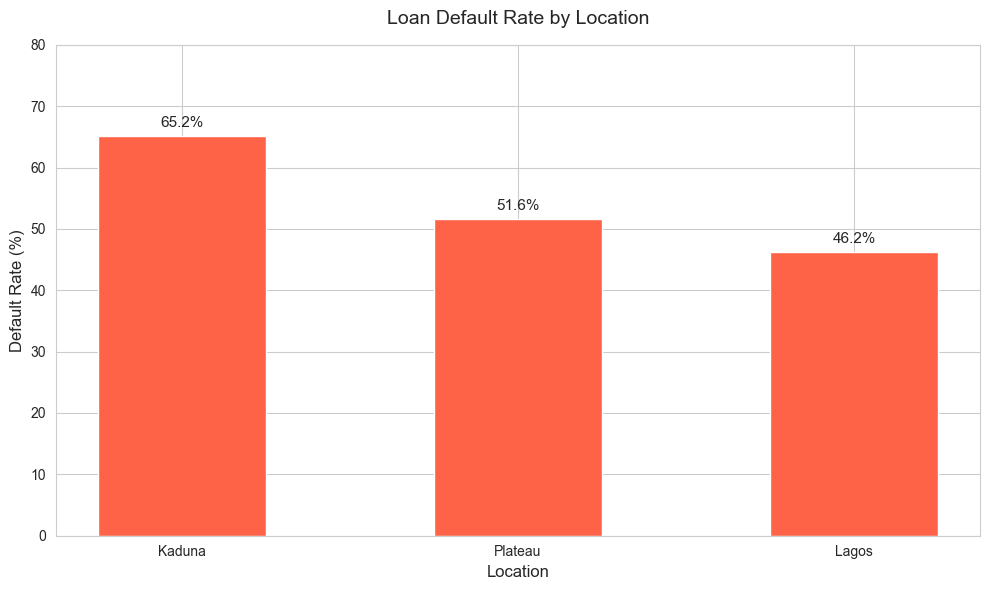

In [9]:
# Default rate by location analysis


# Merge loans with customer location
loans_with_location = loans[loans["loan_taken"] == "Yes"].merge(
    customers[["customer_id", "location"]],
    on="customer_id",
    how="left"
)

# Calculate default rate per location
default_by_location = (
    loans_with_location
    .groupby("location")["loan_defaulted"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(1)
    .reset_index()
)
default_by_location.columns = ["location", "default_rate"]
default_by_location = default_by_location.sort_values("default_rate", ascending=False)

fig, ax = plt.subplots()

ax.bar(
    default_by_location["location"],
    default_by_location["default_rate"],
    color="tomato",
    edgecolor="white",
    width=0.5
)

ax.set_title("Loan Default Rate by Location", pad=15)
ax.set_xlabel("Location")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0, 80)

# Add value labels
for i, row in default_by_location.iterrows():
    ax.text(
        list(default_by_location["location"]).index(row["location"]),
        row["default_rate"] + 1,
        f"{row['default_rate']}%",
        ha="center", va="bottom", fontsize=11
    )

plt.tight_layout()
plt.show()

### Insight 2.3

Default rates vary meaningfully across the three locations:
Kaduna (65.2%), Plateau (51.6%), and Lagos (46.2%) — a 19 percentage
point spread between the highest and lowest risk locations.

The variation is consistent with differences in income levels, economic
activity, and employment structure across these states. Lagos, with its
concentration of formal employment and higher financial literacy, shows
the lowest default rate. Kaduna, with greater dependence on agriculture
and informal income, shows the highest.

Importantly, all three locations show default rates far above sustainable
lending benchmarks — confirming that the portfolio-wide default crisis
was not a localised problem but a systemic one that made the pivot
unavoidable regardless of geography.

## 3. Transaction Behaviour Analysis

### 3.1 Transaction Volume by Month

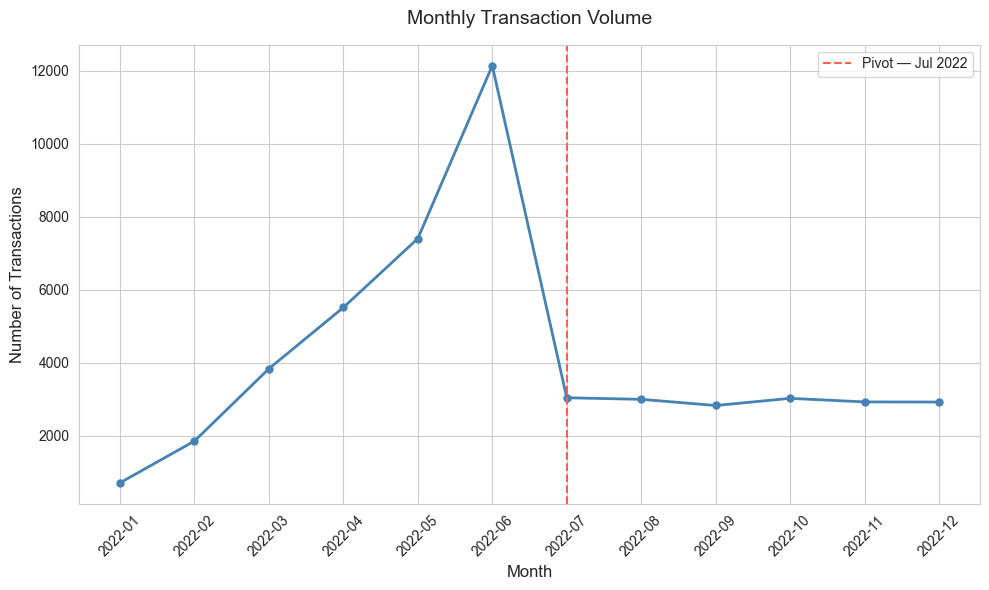

In [10]:
# Transaction volume by month analysis


# Extract year-month from transaction_date
transactions["year_month"] = transactions["transaction_date"].dt.to_period("M")

# Count transactions per month
monthly_volume = (
    transactions
    .groupby("year_month")
    .size()
    .reset_index(name="transaction_count")
)

monthly_volume["year_month_str"] = monthly_volume["year_month"].astype(str)

fig, ax = plt.subplots()

ax.plot(
    monthly_volume["year_month_str"],
    monthly_volume["transaction_count"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=5
)

# Add pivot line
ax.axvline(x="2022-07", color="tomato", linestyle="--", linewidth=1.5, label="Pivot — Jul 2022")

ax.set_title("Monthly Transaction Volume", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Transactions")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

### Insight 3.1

Transaction volume grew steadily from approximately 1,000 in January 2022
to a peak of 12,121 in June 2022 — the final month before the pivot.
The pre-pivot growth reflects both increasing customer acquisition and
accumulating engagement as newer customers became more active over time.

From July 2022, transaction volume dropped sharply to approximately 3,000
per month and remained flat through December — a decline of roughly 75%
from the June peak. The immediate and sustained nature of this drop
confirms that the pivot triggered an engagement collapse rather than a
gradual transition.

The post-pivot plateau at ~3,000 transactions per month represents the
residual activity of customers who found value in the transactional
product suite after loans were discontinued.

### 3.2 Transaction Type Breakdown

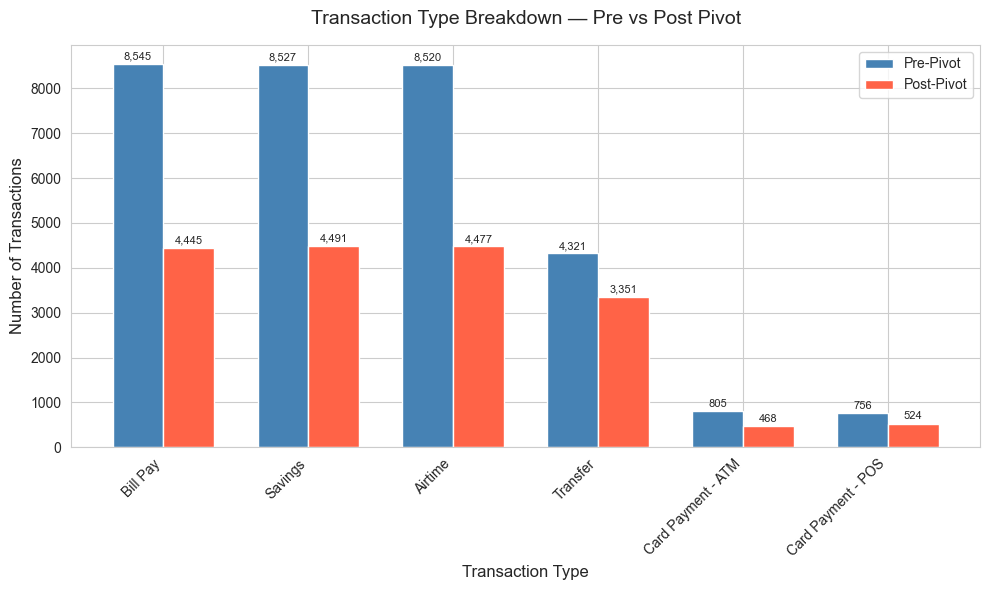

In [11]:
# pre vs post-pivot transaction type by volume analysis


# Label periods
transactions["period"] = transactions["transaction_date"].apply(
    lambda x: "Pre-Pivot" if x < pd.Timestamp("2022-07-01") else "Post-Pivot"
)

# Count transactions by type and period
txn_by_type_period = (
    transactions
    .groupby(["transaction_type", "period"])
    .size()
    .reset_index(name="count")
)

# Pivot for side by side comparison
txn_pivot = txn_by_type_period.pivot(
    index="transaction_type",
    columns="period",
    values="count"
).fillna(0).astype(int)

# Sort by pre-pivot volume
txn_pivot = txn_pivot.sort_values("Pre-Pivot", ascending=False)

fig, ax = plt.subplots()

x         = range(len(txn_pivot))
width     = 0.35
pre_vals  = txn_pivot["Pre-Pivot"]
post_vals = txn_pivot["Post-Pivot"]

bars1 = ax.bar([i - width/2 for i in x], pre_vals,  width, label="Pre-Pivot",  color="steelblue", edgecolor="white")
bars2 = ax.bar([i + width/2 for i in x], post_vals, width, label="Post-Pivot", color="tomato",    edgecolor="white")

# Add value labels on top of each bar
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{bar.get_height():,}",
        ha="center", va="bottom", fontsize=8
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{bar.get_height():,}",
        ha="center", va="bottom", fontsize=8
    )

ax.set_title("Transaction Type Breakdown — Pre vs Post Pivot", pad=15)
ax.set_xlabel("Transaction Type")
ax.set_ylabel("Number of Transactions")
ax.set_xticks(list(x))
ax.set_xticklabels(txn_pivot.index, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

### Insight 3.2

All transaction types declined post-pivot, confirming a broad engagement
collapse following the removal of loans.

Bill Pay, Savings, and Airtime — the three transaction types accessible
to all customers regardless of KYC tier — each dropped by approximately
47–48%. This is consistent with a large volume of Tier 1 loan-focused
customers disengaging after loans were discontinued.

Transfer showed the smallest proportional decline at 22.4%, suggesting
that Tier 2 and above customers — who had completed more verification
and likely had broader product interest — were more resilient post-pivot.

Card Payments declined by 31–42% but represent a small share of overall
transaction volume, reflecting their restriction to the smallest customer
segment (Tier 3 only, 10.3% of the base).

### 3.3 Active Customers — Pre vs Post Pivot

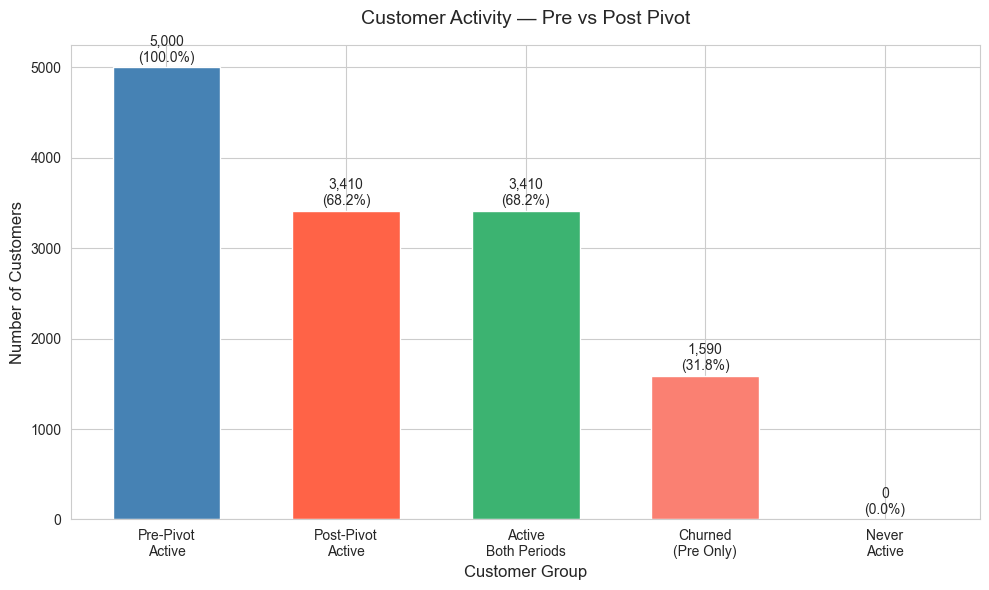

In [12]:
# pre vs post-pivot active customers analysis


# Count unique active customers per period
pre_active  = transactions[transactions["period"] == "Pre-Pivot"]["customer_id"].nunique()
post_active = transactions[transactions["period"] == "Post-Pivot"]["customer_id"].nunique()
total       = customers["customer_id"].nunique()

# Customers who were active pre-pivot but completely inactive post-pivot
pre_custs  = set(transactions[transactions["period"] == "Pre-Pivot"]["customer_id"])
post_custs = set(transactions[transactions["period"] == "Post-Pivot"]["customer_id"])
churned    = len(pre_custs - post_custs)
retained   = len(pre_custs & post_custs)
never_active = total - len(pre_custs)


# Visualise
fig, ax = plt.subplots()

categories = ["Pre-Pivot\nActive", "Post-Pivot\nActive", "Active\nBoth Periods",
              "Churned\n(Pre Only)", "Never\nActive"]
values     = [pre_active, post_active, retained, churned, never_active]
colors     = ["steelblue", "tomato", "mediumseagreen", "salmon", "lightgrey"]

bars = ax.bar(categories, values, color=colors, edgecolor="white", width=0.6)

ax.set_title("Customer Activity — Pre vs Post Pivot", pad=15)
ax.set_xlabel("Customer Group")
ax.set_ylabel("Number of Customers")

# Add value labels
for bar, val in zip(bars, values):
    pct = val / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.show()

### Insight 3.3

All 5,000 customers were active during the pre-pivot period — confirming
full engagement before loans were discontinued.

Following the pivot, 1,590 customers (31.8%) churned completely —
transacting before July 2022 but making zero transactions afterward.
These customers are effectively lost to the platform.

3,410 customers (68.2%) remained active in both periods, representing
the retained base the company must now understand and serve. However
remaining active does not necessarily mean deeply engaged — some of
these customers may have made only one or two post-pivot transactions
before going dormant.

This distinction between technically retained and genuinely engaged
customers is the central question the segmentation model will answer.

### 3.4 Post-Pivot Transaction Frequency per Retained Customer

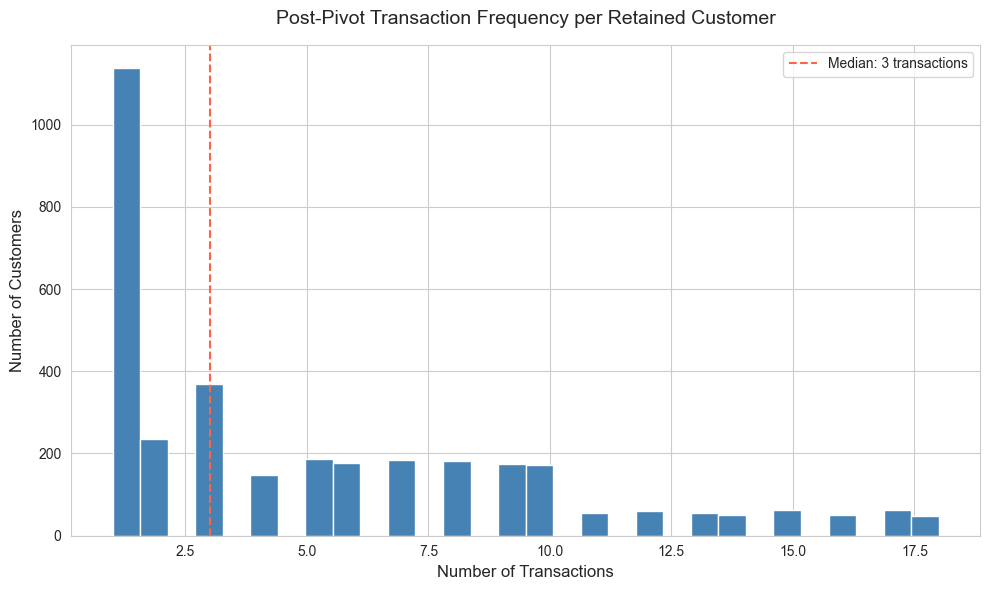

In [13]:
# Retained customer transaction frequency post-pivot analysis


# Count post-pivot transactions per customer
post_pivot_txns = transactions[transactions["period"] == "Post-Pivot"]

post_freq = (
    post_pivot_txns
    .groupby("customer_id")
    .size()
    .reset_index(name="txn_count")
)

fig, ax = plt.subplots()

ax.hist(
    post_freq["txn_count"],
    bins=30,
    color="steelblue",
    edgecolor="white"
)

ax.axvline(
    post_freq["txn_count"].median(),
    color="tomato",
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {post_freq['txn_count'].median():.0f} transactions"
)

ax.set_title("Post-Pivot Transaction Frequency per Retained Customer", pad=15)
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

### Insight 3.4

Among the 3,410 retained customers, post-pivot transaction frequency
is heavily right-skewed with a median of just 3 transactions over the
entire 6-month post-pivot period — approximately one transaction every
two months.

The distribution reveals three broad behavioural groups within the
retained base:
- A large group of lightly engaged customers (1–3 transactions) who
  are technically retained but behaviourally dormant
- A moderate group with some engagement (4–10 transactions)
- A small highly active core (10+ transactions) representing genuine
  post-pivot adoption

This heterogeneity within the retained base is precisely why segmentation
is needed — aggregate retention figures mask fundamentally different
customer behaviours that require different product and growth strategies.

### 3.5 Post-Pivot Transaction Amount Distribution per Customer

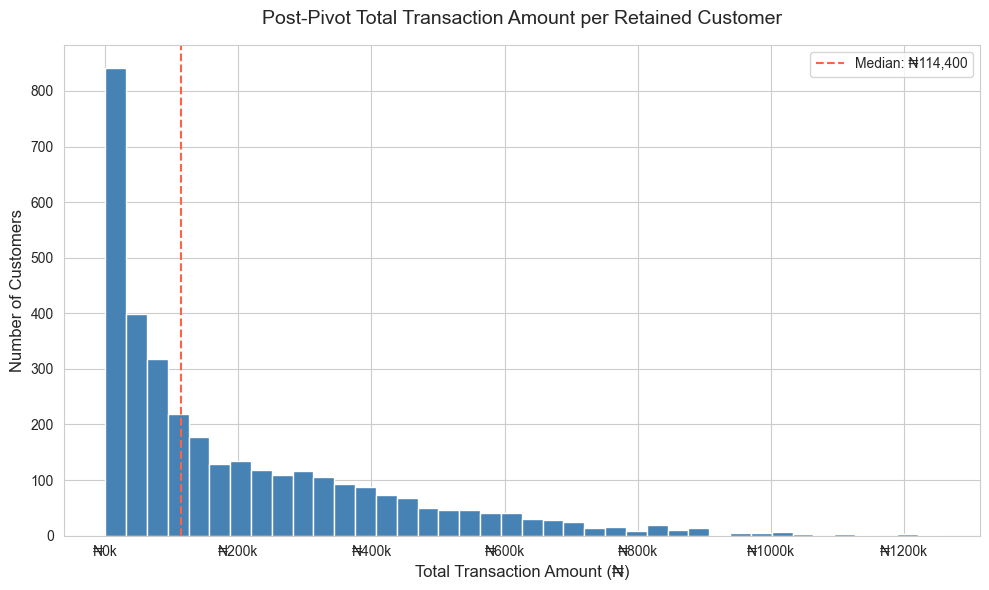

In [14]:
# Total transaction amount per customer post-pivot
post_monetary = (
    post_pivot_txns
    .groupby("customer_id")["amount"]
    .sum()
    .reset_index(name="total_amount")
)

fig, ax = plt.subplots()

ax.hist(
    post_monetary["total_amount"],
    bins=40,
    color="steelblue",
    edgecolor="white"
)

ax.axvline(
    post_monetary["total_amount"].median(),
    color="tomato",
    linestyle="--",
    linewidth=1.5,
    label=f"Median: ₦{post_monetary['total_amount'].median():,.0f}"
)

ax.set_title("Post-Pivot Total Transaction Amount per Retained Customer", pad=15)
ax.set_xlabel("Total Transaction Amount (₦)")
ax.set_ylabel("Number of Customers")
ax.legend()

# Format x-axis in thousands
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"₦{x/1000:.0f}k")
)

plt.tight_layout()
plt.show()

### Insight 3.5

Post-pivot total transaction amounts per retained customer are heavily
right-skewed, with a median of ₦114,400 over the 6-month post-pivot
period — approximately ₦19,000 per month per customer.

The majority of retained customers are concentrated in the low-spend
bracket (under ₦100k total), consistent with the low transaction
frequency observed in chart 3.4. A smaller high-value tail of customers
spending ₦500k–₦1,200k+ represents a disproportionately valuable segment
worth identifying and protecting.

Taken together with the frequency distribution, charts 3.4 and 3.5
confirm that the retained base contains distinct behavioural tiers —
from lightly engaged low-spenders to highly active high-value customers.
Segmentation will formalise these tiers into actionable customer groups.

## 4. Key Findings Summary

### Customer Profile
- Loan Campaign is the dominant acquisition channel at 40.3% of the customer base
- 51.1% of customers are Tier 1 - limited to Airtime, Bill Pay, and Savings only
- 65.8% of customers are based in Lagos, consistent with the company's physical campaign focus

### Loan Behaviour
- 55.9% of customers took a loan - nearly half the base never did
- 50% default rate among loan takers - far above sustainable lending benchmarks
- Default rates vary by location: Kaduna (65.2%), Plateau (51.6%), Lagos (46.2%)
- The default crisis was systemic across all locations, making the pivot unavoidable

### Transaction Behaviour
- Transaction volume peaked at 12,121 in June 2022 then dropped 75% immediately after the pivot
- All transaction types declined post-pivot - Bill Pay, Savings, and Airtime dropped ~48% each
- Transfer showed the smallest decline at 22.4% - the most resilient post-pivot product
- 1,590 customers (31.8%) churned completely - zero post-pivot transactions
- 3,410 customers (68.2%) technically retained but median post-pivot frequency is only 3 transactions
- Median post-pivot spend is ₦114,400 over 6 months - modest but with a high-value tail

### The Central Segmentation Question
The retained base of 3,410 customers is not homogeneous. A small highly
active, high-spending core coexists with a large lightly engaged majority.
1,590 customers have already churned entirely. Understanding who these
different groups are and what differentiates them is the goal of the
segmentation model